## 머신러닝 회귀 (Regression) 

> **"과거 데이터로 미래의 숫자를 예측한다"** — 그것이 회귀입니다.

**사용 데이터**: `car.csv` — 중고차 판매 데이터 
**예측 목표**: 차량의 특성(연식, 주행거리 등)으로 **가격** 을 예측

## 회귀란 무엇인가?

### 분류(Classification) vs 회귀(Regression)

머신러닝의 지도 학습은 크게 두 가지로 나뉩니다.

| 구분 | 분류 (Classification) | 회귀 (Regression) |
|------|-----------------------|-------------------|
| **예측하는 것** | 카테고리 (범주) | 연속적인 숫자 |
| **출력 예시** | 품종, 암 / 양성 |  725 , 15.3  |
| **평가 지표** | 정확도, 정밀도, 재현율,F1-score | MAE, RMSE, R² |
| **실생활 예시** | 암 진단, 스팸 필터 | **집값 예측, 기온 예측** |



### 회귀 직관적으로 이해하기

```
       가격 
  40000 │                     ○
        │             ○   ○
  30000 │         ○      ○
        │     ○ ○    ○
  20000 │   ○   ○           ← 실제 데이터 점들
        │ ○  ○
  10000 │─────────────────────── 주행거리
```

회귀 :  이 점들을 **가장 잘 관통하는 직선(또는 곡선)** 을 찾는 것  
그 직선으로 새로운 차의 가격을 **예측**합니다.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

##  데이터 탐색 (EDA)

### car.csv 컬럼 설명

| 컬럼 | 설명 | 타입 | 예시 |
|------|------|------|------|
| `model` | 차량 모델명 | 범주형 | Fiesta, Focus |
| `year` | 연식 | 수치형 | 2018 |
| **`price`** | **가격 ← 예측 목표** | **수치형** | **10,600** |
| `transmission` | 변속기 유형 | 범주형 | Manual, Automatic |
| `mileage` | 주행거리 (마일) | 수치형 | 27,380 |
| `fuelType` | 연료 유형 | 범주형 | Petrol, Diesel |
| `tax` | 자동차세 (£/년) | 수치형 | 145 |
| `mpg` | 연비 (miles per gallon) | 수치형 | 56.5 |
| `engineSize` | 배기량 (리터) | 수치형 | 1.0 |

In [31]:
df = pd.read_csv('car.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2018,10600,Manual,27380,Petrol,145,56.5,1.0
1,Fiesta,2018,11000,Manual,7724,Petrol,145,65.7,1.0
2,Fiesta,2014,7291,Manual,23894,Petrol,30,54.3,1.2
3,Fiesta,2014,6998,Manual,20325,Petrol,30,54.3,1.2
4,Fiesta,2018,11800,Manual,34671,Petrol,145,65.7,1.0
...,...,...,...,...,...,...,...,...,...
1367,Fiesta,2014,6999,Manual,50000,Petrol,0,65.7,1.0
1368,Fiesta,2016,7999,Manual,30900,Petrol,0,65.7,1.0
1369,Fiesta,2018,17295,Automatic,431,Petrol,145,48.7,1.0
1370,Fiesta,2017,10495,Automatic,31597,Petrol,0,57.7,1.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         1372 non-null   object 
 1   year          1372 non-null   int64  
 2   price         1372 non-null   int64  
 3   transmission  1372 non-null   object 
 4   mileage       1372 non-null   int64  
 5   fuelType      1372 non-null   object 
 6   tax           1372 non-null   int64  
 7   mpg           1372 non-null   float64
 8   engineSize    1372 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 96.6+ KB


In [33]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,1372.000000,1372.000000,1372.000000,1372.00000,1372.000000,1372.000000
mean,2016.870262,10246.741254,21615.703353,101.62172,60.831050,1.093659
std,2.286373,2871.141723,16195.652603,64.20709,7.603176,0.183083
min,2004.000000,1295.000000,5.000000,0.00000,40.300000,0.000000
25%,2016.000000,8399.750000,10235.250000,20.00000,54.300000,1.000000
50%,2017.000000,9998.000000,17611.500000,145.00000,62.800000,1.000000
75%,2018.000000,11888.250000,28849.250000,145.00000,65.700000,1.200000
max,2060.000000,19999.000000,119000.000000,205.00000,88.300000,1.600000


In [34]:
df.describe(include='all')

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
count,1372,1372.000000,1372.000000,1372,1372.000000,1372,1372.00000,1372.000000,1372.000000
unique,1,NaN,NaN,3,NaN,2,NaN,NaN,NaN
top,Fiesta,NaN,NaN,Manual,NaN,Petrol,NaN,NaN,NaN
freq,1372,NaN,NaN,1270,NaN,1299,NaN,NaN,NaN
mean,NaN,2016.870262,10246.741254,NaN,21615.703353,NaN,101.62172,60.831050,1.093659
std,NaN,2.286373,2871.141723,NaN,16195.652603,NaN,64.20709,7.603176,0.183083
min,NaN,2004.000000,1295.000000,NaN,5.000000,NaN,0.00000,40.300000,0.000000
25%,NaN,2016.000000,8399.750000,NaN,10235.250000,NaN,20.00000,54.300000,1.000000
50%,NaN,2017.000000,9998.000000,NaN,17611.500000,NaN,145.00000,62.800000,1.000000
75%,NaN,2018.000000,11888.250000,NaN,28849.250000,NaN,145.00000,65.700000,1.200000


In [35]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [36]:
df['model'].value_counts()

model
Fiesta    1372
Name: count, dtype: int64

In [37]:
df['transmission'].value_counts()

transmission
Manual       1270
Semi-Auto      62
Automatic      40
Name: count, dtype: int64

In [38]:
df['fuelType'].value_counts()

fuelType
Petrol    1299
Diesel      73
Name: count, dtype: int64

In [39]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

<Axes: xlabel='price', ylabel='Count'>

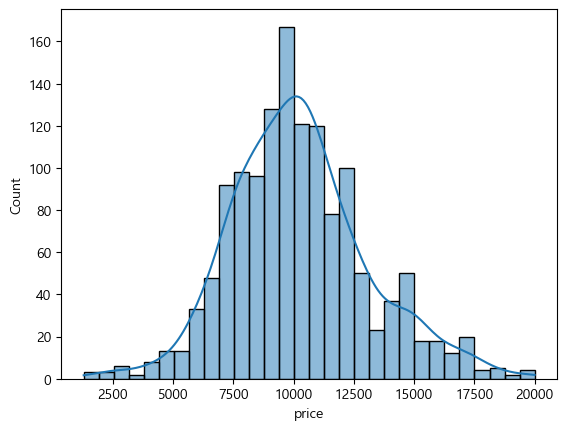

In [40]:
sns.histplot(data=df, x='price' ,bins=30, kde=True)

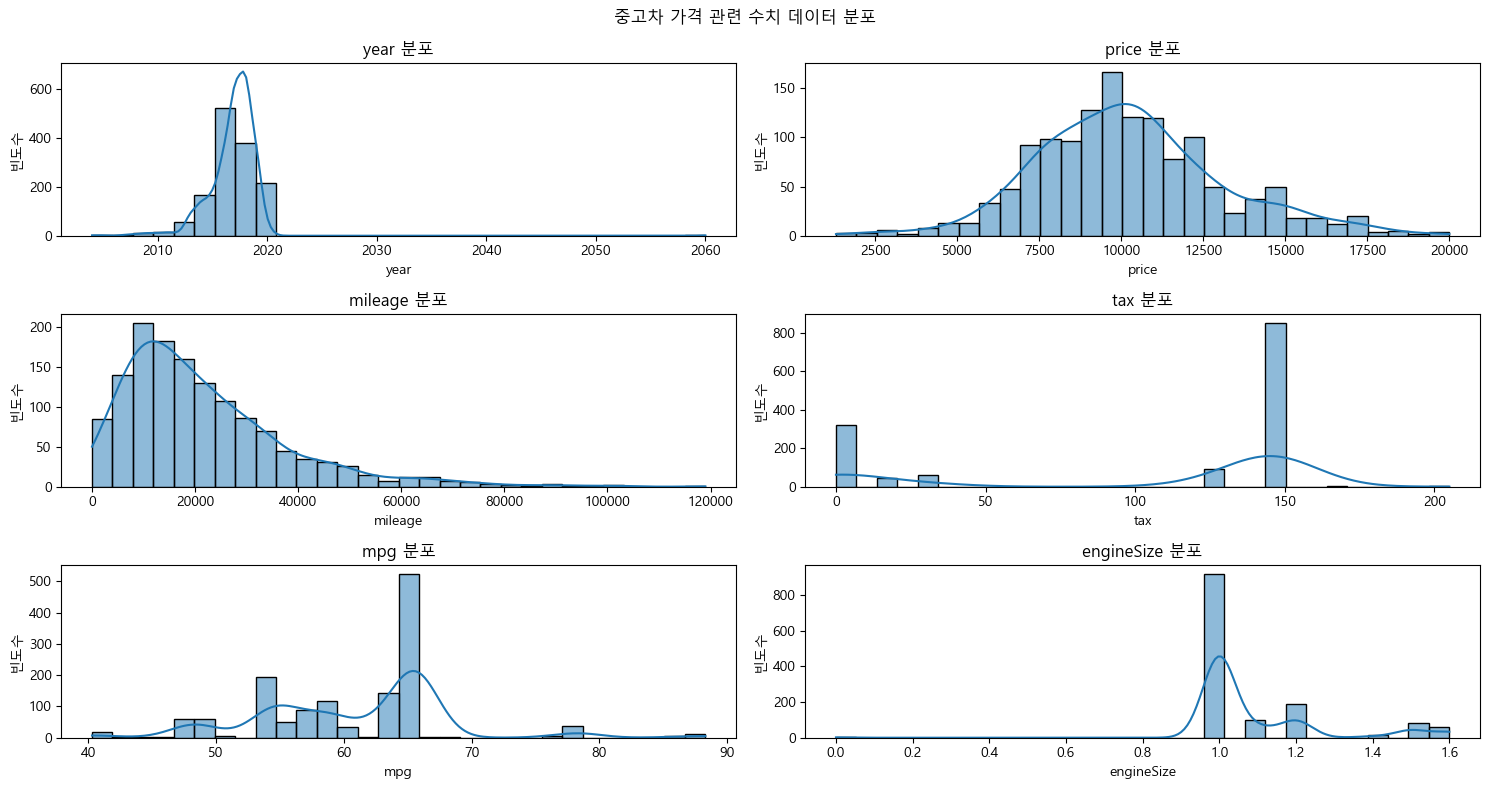

In [41]:
fig , axes =plt.subplots(3, 2, figsize=(15,8))
axes = axes.flatten()
cols = ['year', 'price', 'mileage',  'tax', 'mpg', 'engineSize']
for i , col  in enumerate(cols) :
    sns.histplot(data=df, x=col ,bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{col} 분포')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('빈도수')

plt.suptitle('중고차 가격 관련 수치 데이터 분포')
plt.tight_layout()
plt.show()

### 특성과 가격의 관계 살펴보기

회귀에서 가장 먼저 해야 할 일 → **각 특성이 가격과 어떤 관계인지 확인**

- 주행거리가 많을수록 가격이 낮을까?
- 최신 연식일수록 가격이 높을까?
- 배기량이 클수록 가격이 높을까?

**산점도(Scatter Plot)** 로 한눈에 확인합니다.

In [42]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

<Axes: xlabel='year', ylabel='price'>

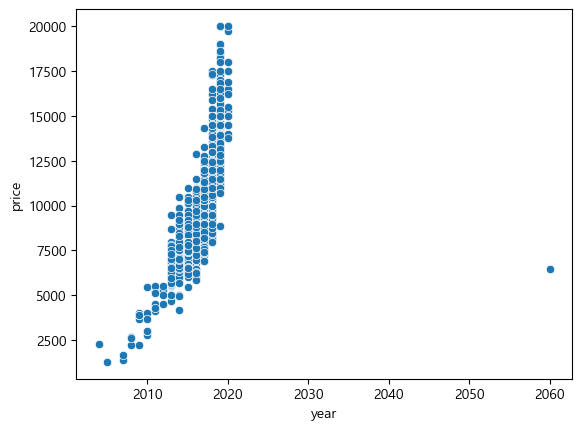

In [43]:
sns.scatterplot(data=df, x= 'year',    y='price')

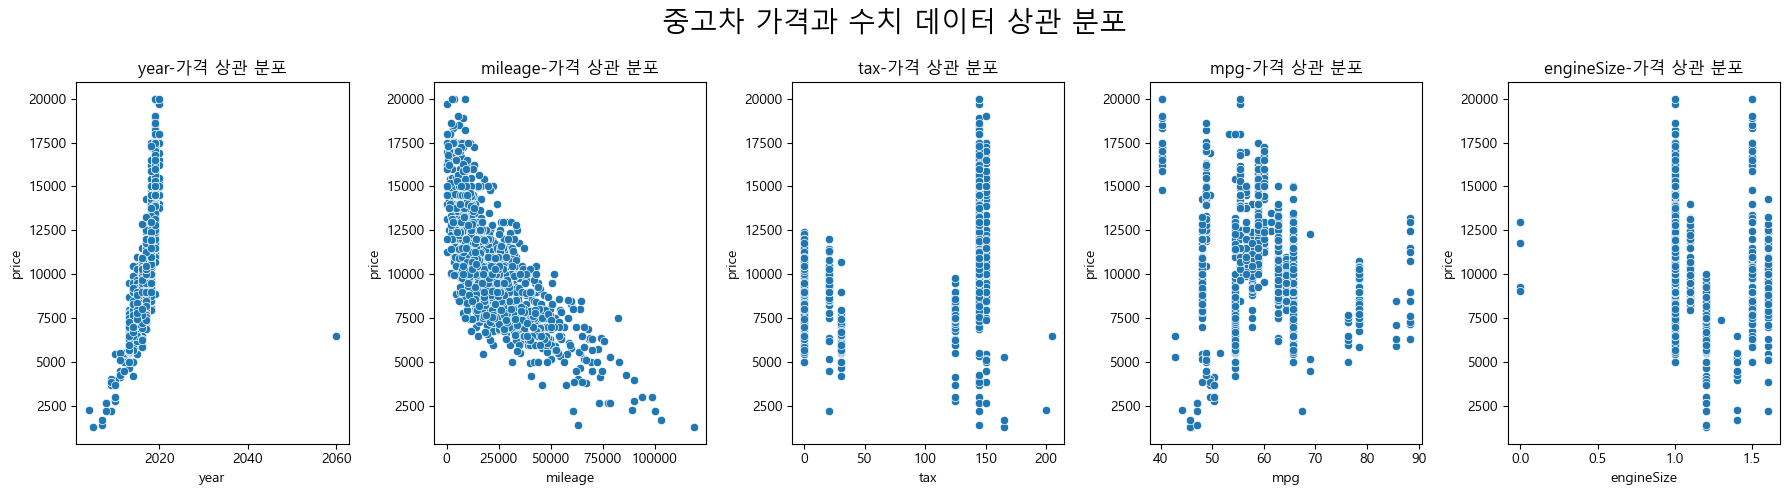

In [44]:
cols=['year',  'mileage',  'tax', 'mpg','engineSize' ]

fig, axes =plt.subplots(1,5, figsize=(18,5))

for i, col  in enumerate(cols) :
    sns.scatterplot(data=df, x= col,    y='price',  ax=axes[i]  )
    axes[i].set_title(f'{col}-가격 상관 분포')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')

fig.suptitle('중고차 가격과 수치 데이터 상관 분포', fontsize=20)
plt.tight_layout()
plt.show() 

### 상관계수 히트맵
>  상관계수: -1 ~ +1  /  +1에 가까울수록 같이 증가, -1에 가까울수록 반대로 움직임

In [45]:
corr = df[[ 'year',  'mileage',  'tax', 'mpg','engineSize' ]].corr().round(2)
corr

,year,mileage,tax,mpg,engineSize
year,1.00,-0.60,0.43,0.00,-0.25
mileage,-0.60,1.00,-0.33,0.04,0.29
tax,0.43,-0.33,1.00,-0.38,0.04
mpg,0.00,0.04,-0.38,1.00,-0.18
engineSize,-0.25,0.29,0.04,-0.18,1.00


<Axes: >

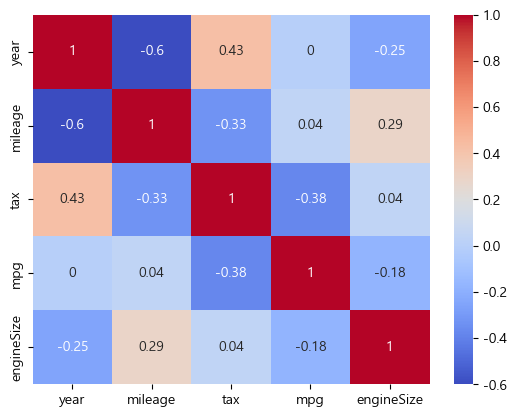

In [46]:
sns.heatmap(corr, annot=True, cmap='coolwarm')


##   선형 회귀 (Simple Linear Regression)

###  핵심 아이디어: 직선 하나로 예측하기

```
가격  ↑
         │  ○
   30000 │      ○
         │  ○     
   20000 │    ○  ←── 점들을 가장 잘 관통하는 직선을 찾음
         │  ○         y = ax + b
   10000 │──────────────────────────── 주행거리
              0     50000    100000
```

$$\hat{y} = a \times x + b$$

| 기호 | 이름 | 의미 |
|------|------|------|
| $\hat{y}$ | 예측값 | 모델이 추정한 가격 |
| $x$ | 입력 특성 | 주행거리 |
| $a$ | 기울기 (coefficient) | x가 1 증가할 때 y의 변화량 |
| $b$ | 절편 (intercept) | x = 0일 때의 y 값 |



###  sklearn의 회귀 4단계

```python
# 1. 모델 객체 만들기
model = LinearRegression()

# 2. 학습 (최적의 a, b 찾기)
model.fit(X_train, y_train)

# 3. 예측
y_pred = model.predict(X_test)

# 4. 평가
r2_score(y_test, y_pred)
```

분류 모델과 **완전히 같은 패턴**입니다!

In [47]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [48]:
X=df[['mileage' ]]     # 주의!! 대괄호 2개!
y=df['price']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [50]:
model =LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
y_pred = model.predict(X_test)
y_pred

array([12277.87505579,  8567.07817185,  7623.90942064,  9654.41916403,
       12634.52491761,  8725.61722704, 11098.6620674 , 12242.33609429,
       10216.48926429,  8630.72063836, 12137.10548135, 12875.86219161,
       10691.09823237,  9442.94974065,  8704.19303039, 11476.73612588,
        8123.34525189, 11623.93295931, 11560.03844343, 11179.56991592,
       10861.86168211, 11407.04447443,  9396.0685574 , 11338.48704516,
       12026.95990564, 10720.58800893,  9530.15882347, 10777.17309301,
       11591.16654091, 11862.74973958, 10077.73608483,  9217.99567586,
       12025.44760941, 11844.72820946, 12837.80273639, 10244.21469525,
       11048.25219294,  1142.71186089, 11016.87204608,  8095.49379625,
        8986.86640145, 11471.82116312, 12779.95740544,  7601.98112525,
        7721.45252773,  7954.47217244, 12290.72957377, 12554.87731596,
        9569.60455024, 10418.12876215,  7645.58566666, 11994.5715613 ,
       11412.08546188, 12247.12503236, 11297.1509481 , -2007.90529307,
      

In [53]:
mean_absolute_error(y_test, y_pred)

1562.2091020923426

In [54]:
round(mean_absolute_error(y_test, y_pred), 2)

1562.21

##  회귀 모델 평가 지표

분류 모델은 "정확도(Accuracy)"로 평가했습니다.  
회귀 모델은 **예측값과 실제값의 차이(오차)** 로 평가합니다.



###  세 가지 주요 지표

**① MAE (Mean Absolute Error, 평균 절대 오차)**

$$\text{MAE} = \frac{1}{n}\sum|y_i - \hat{y}_i|$$

- 오차의 절댓값 평균
- **단위가 원래 데이터와 같음** → 해석이 직관적
- 예: MAE = £2,000 → "평균적으로 실제 가격과 £2,000 차이"

---

**② RMSE (Root Mean Squared Error, 평균 제곱근 오차)**

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$$

- 오차를 제곱한 뒤 평균 → 루트
- **큰 오차에 더 민감** (제곱 때문)
- 보통 MAE보다 값이 큼

---

**③ R² (결정 계수, R-squared)**

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- 0 ~ 1 사이 값 (1에 가까울수록 좋음)
- **"이 모델이 가격 변동의 몇 %를 설명하는가"** 를 나타냄
- 예: R² = 0.85 → 가격 변동의 85%를 이 모델이 설명

| 지표 | 작을수록? 클수록? | 단위 | 직관 |
|------|-----------------|------|------|
| MAE  | 작을수록 좋음 | 원래 단위(£) | 평균 오차 |
| RMSE | 작을수록 좋음 | 원래 단위(£) | 큰 오차에 민감 |
| R²   | **클수록** 좋음 | 없음 (0~1) | 설명력 |

여러분 오늘은 새로운 내용이 많았습니다   
어려우셨나요? 그래도 우리는 **많은 경험**을 하는 것이 중요합니다!!     
기계학습의 분류에 대해 어느 정도 익숙해지셨으면 합니다     
처음 배운 회귀는 가격과 같은 것을 예측하는 것이구나 정도를 느끼고     
다음 시간에 공공데이터 등을 가지고 실습하면 더 감이 오실 거에요      
13주차 수업 후에는 **프로젝트 제안서** 를 토론방에 제출하게 되니 주제와 데이터에 대해 생각해보세요            
아래 빈 셀에 공부하면서의 어려분의 이야기를 적어 저와 공유해주세요!!

내용이 좀 어려웠지만 분류와 회귀의 차이를 알 수 있었고,
실습을 하면서 부족한 부분을 채워나가겠습니다